## Outros algoritmos

### Base de dados cobertura vegetal

base de dados de cobertura vegetal, explorada nos exercícios da **Parte 1 - Classificação**.

Comece carregando os dados do arquivo `cov_types.csv` armazenado na pasta


In [48]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [49]:
# no github
# Machine_Learning/Machine_Learning_AZ/8-Redes_neurais_artificiais/novo_exercicios/cov_types.csv

In [50]:
import os
DRIVE_DIRECTORY = "../10-Redes_neurais_artificiais/exercicios/novo"

base = pd.read_csv(os.path.join(DRIVE_DIRECTORY, 'cov_types.csv'))

In [51]:
base.tail(5)

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type,Cover_Type
9995,2917.0,90.0,9.0,247.0,25.0,4095.0,235.0,225.0,121.0,3901.0,0,28,Lodgepole Pine
9996,3015.0,38.0,8.0,361.0,74.0,4846.0,220.0,223.0,138.0,1611.0,0,28,Lodgepole Pine
9997,3052.0,79.0,19.0,90.0,11.0,1003.0,241.0,203.0,85.0,1490.0,2,22,Spruce/Fir
9998,2958.0,58.0,6.0,319.0,19.0,2468.0,225.0,227.0,137.0,2280.0,0,28,Lodgepole Pine
9999,2682.0,91.0,13.0,162.0,32.0,1369.0,240.0,219.0,108.0,1661.0,2,10,Lodgepole Pine


Remova as colunas categóricas, `Wilderness_Area` e `Soil_Type`.

In [52]:
base = base.drop(["Wilderness_Area", "Soil_Type"], axis=1)

Separe a coluna com a variável alvo `Cover_Type` em uma variável `y`.

In [53]:
y = base["Cover_Type"]

Separe as demais colunas em uma variável `X`, no formato de NumPy array.

In [54]:
list(base.iloc[:, :-1].columns) # analise com as colunas de interesse

['Elevation',
 'Aspect',
 'Slope',
 'Horizontal_Distance_To_Hydrology',
 'Vertical_Distance_To_Hydrology',
 'Horizontal_Distance_To_Roadways',
 'Hillshade_9am',
 'Hillshade_Noon',
 'Hillshade_3pm',
 'Horizontal_Distance_To_Fire_Points']

In [55]:
X = base.iloc[:, :-1].values

In [56]:
X

array([[2767.,   66.,   17., ...,  204.,   96., 2251.],
       [2724.,  160.,   19., ...,  240.,  127., 2514.],
       [2360.,   65.,    7., ...,  226.,  134.,  339.],
       ...,
       [3052.,   79.,   19., ...,  203.,   85., 1490.],
       [2958.,   58.,    6., ...,  227.,  137., 2280.],
       [2682.,   91.,   13., ...,  219.,  108., 1661.]])

## Escalone os valores de `X` utilizando `StandardScaler`.

In [57]:
scaler = StandardScaler()
X = scaler.fit_transform(X) # tranformar a normalização, média e o desvio padrão

In [58]:
X

array([[-0.71700375, -0.78934465,  0.38187624, ..., -0.96994893,
        -1.19597298,  0.19948581],
       [-0.87120088,  0.05516249,  0.6497092 , ...,  0.84361411,
        -0.38987904,  0.39804796],
       [-2.17649753, -0.79832877, -0.95728858, ...,  0.1383396 ,
        -0.20785782, -1.2440535 ],
       ...,
       [ 0.30500049, -0.67255111,  0.6497092 , ..., -1.02032568,
        -1.48200632, -0.37506096],
       [-0.03208161, -0.8612176 , -1.09120506, ...,  0.18871635,
        -0.12984873,  0.22138049],
       [-1.02181203, -0.56474169, -0.15378969, ..., -0.21429766,
        -0.88393662, -0.24595781]])

### Agora gere um dendograma de `X`, utilizando `method=ward`. Exiba o dendrograma gerado.

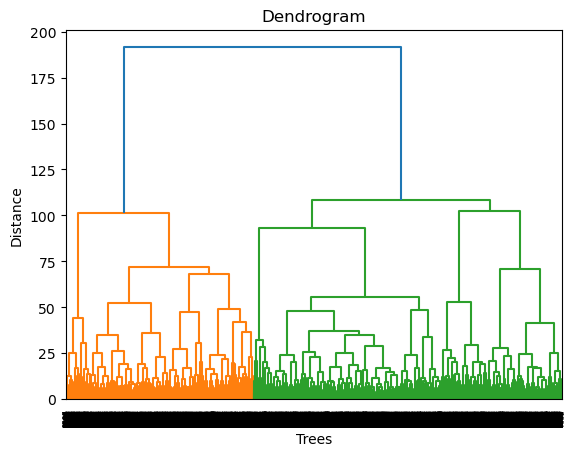

In [59]:
dendrogram = dendrogram(linkage(X, method="ward"))
plt.title("Dendrogram")
plt.xlabel("Trees")
plt.ylabel("Distance")
plt.show()

In [60]:
# agromeramos o cluster

### Agrupe os dados com `AgglomerativeClustering`, utilizando `n_clusters=7`,  `metric="euclidean"` e `linkage="ward"`. Recupere os rótulos com `fit_predict`.

In [61]:
agg = AgglomerativeClustering(n_clusters=7, metric="euclidean", linkage="ward")
labels = agg.fit_predict(X)

In [62]:
agg.get_params()

{'compute_distances': False,
 'compute_full_tree': 'auto',
 'connectivity': None,
 'distance_threshold': None,
 'linkage': 'ward',
 'memory': None,
 'metric': 'euclidean',
 'n_clusters': 7}

### Vamos visualizar os dados junto com os rótulos gerados. Comece transformando `X` com a técnica de PCA, utilizando 2 componentes.

In [63]:
list(base.iloc[:, :-1].columns)

['Elevation',
 'Aspect',
 'Slope',
 'Horizontal_Distance_To_Hydrology',
 'Vertical_Distance_To_Hydrology',
 'Horizontal_Distance_To_Roadways',
 'Hillshade_9am',
 'Hillshade_Noon',
 'Hillshade_3pm',
 'Horizontal_Distance_To_Fire_Points']

In [64]:
len(list(base.iloc[:, :-1].columns)) # são as quantidades de variáveis que devemos colocar como 2 variáveis

10

In [65]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

## Plote o PCA, utilizando como argumento para cor os rótulos gerados pelo algoritmo, no formato de string.

In [66]:
labels

array([2, 2, 2, ..., 2, 0, 2])

In [67]:
set(labels) # 7 clusters

{0, 1, 2, 3, 4, 5, 6}

o tipo de cobertura do solo ou vegetação de uma área.

Elevation: A altitude do terreno (em metros).

Aspect: A orientação do terreno (em graus, onde 0 é norte e 180 é sul).

Slope: A inclinação do terreno (em graus).

Horizontal_Distance_To_Hydrology: A distância horizontal até a fonte de água mais próxima (como um rio ou lago).

Vertical_Distance_To_Hydrology: A distância vertical até a fonte de água mais próxima.

Horizontal_Distance_To_Roadways: A distância horizontal até a estrada mais próxima.

Hillshade_9am: A sombra do morro às 9 da manhã. É uma medida de quanta luz solar um local recebe.

Hillshade_Noon: A sombra do morro ao meio-dia.

Hillshade_3pm: A sombra do morro às 3 da tarde.

Horizontal_Distance_To_Fire_Points: A distância horizontal até um local de ignição de incêndio florestal.

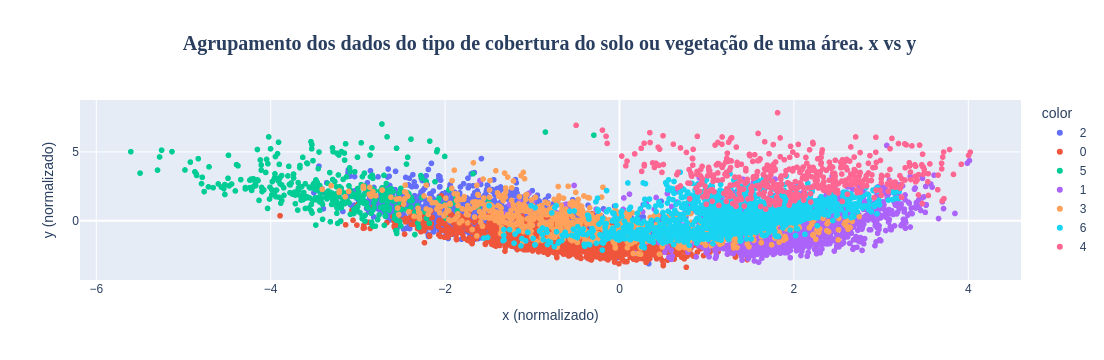

In [68]:
fig = px.scatter(x=X_pca[:, 0], y=X_pca[:, 1], color=labels.astype(str), title='<b>Agrupamento dos dados do tipo de cobertura do solo ou vegetação de uma área. x vs y </b>')

fig.update_layout(
    xaxis_title_text='x (normalizado)',
    yaxis_title_text='y (normalizado)',
    # padrão o título
    title_font_size=20,  # Define o tamanho da fonte do título
    title_font_family='Arial Black', # Uma fonte mais grossa
    title_x=0.5 # Centraliza o título no gráfico
)

fig.show()
fig.write_html("Figuras/19exercicio_grafico1.html")

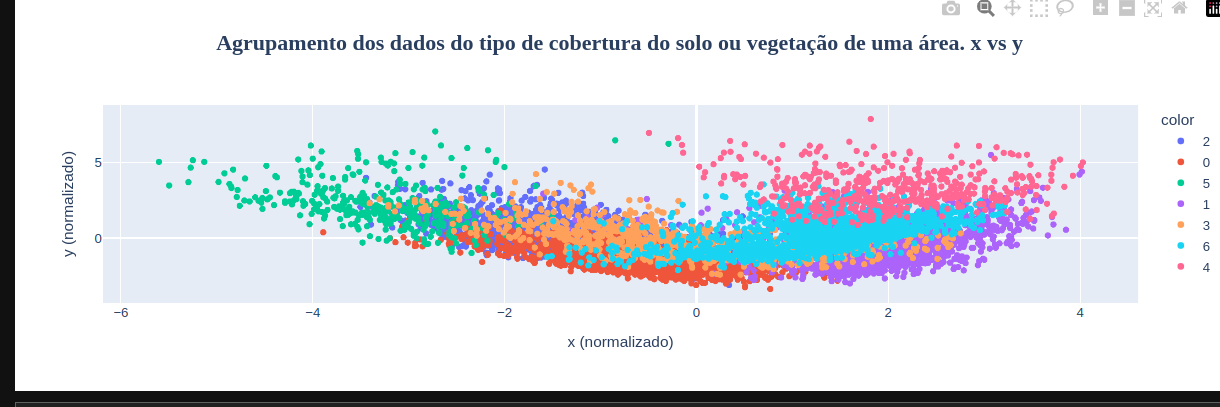

dados separados pelas classes


# comparar os algoritmos

#### Compare os rótulos gerados com as classes originais.

In [69]:
# dados reais comparados
pd.crosstab(labels, y)

Cover_Type,Aspen,Cottonwood/Willow,Douglas-fir,Krummholz,Lodgepole Pine,Ponderosa Pine,Spruce/Fir
row_0,,,,,,,
0,8,0,0,25,820,0,655
1,10,1,13,95,866,32,697
2,78,30,111,108,1740,222,1108
3,18,0,2,66,384,18,432
4,0,3,92,9,136,152,102
5,19,13,26,24,133,72,90
6,30,8,34,35,768,85,630


Novamente, se vê pouca correlação entre os rótulos.

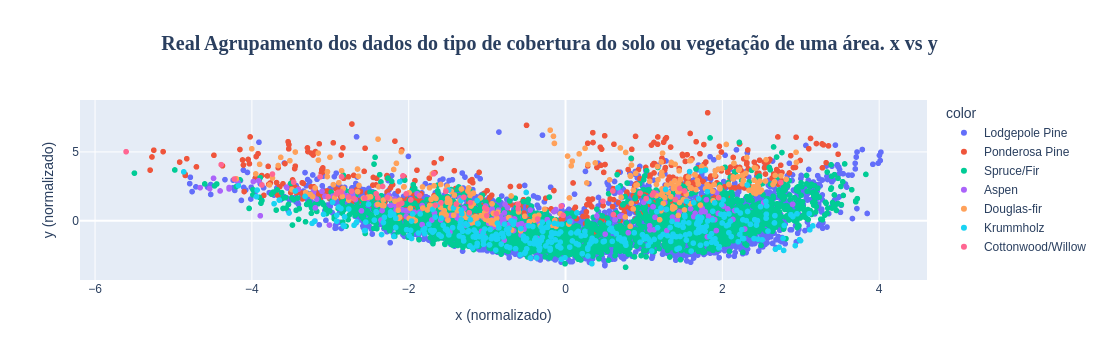

In [70]:
fig = px.scatter(x=X_pca[:, 0], y=X_pca[:, 1], color=y, title='<b>Real Agrupamento dos dados do tipo de cobertura do solo ou vegetação de uma área. x vs y </b>')

fig.update_layout(
    xaxis_title_text='x (normalizado)',
    yaxis_title_text='y (normalizado)',
    # padrão o título
    title_font_size=20,  # Define o tamanho da fonte do título
    title_font_family='Arial Black', # Uma fonte mais grossa
    title_x=0.5 # Centraliza o título no gráfico
)

fig.show()
fig.write_html("Figuras/19exercicio_grafico2.html")

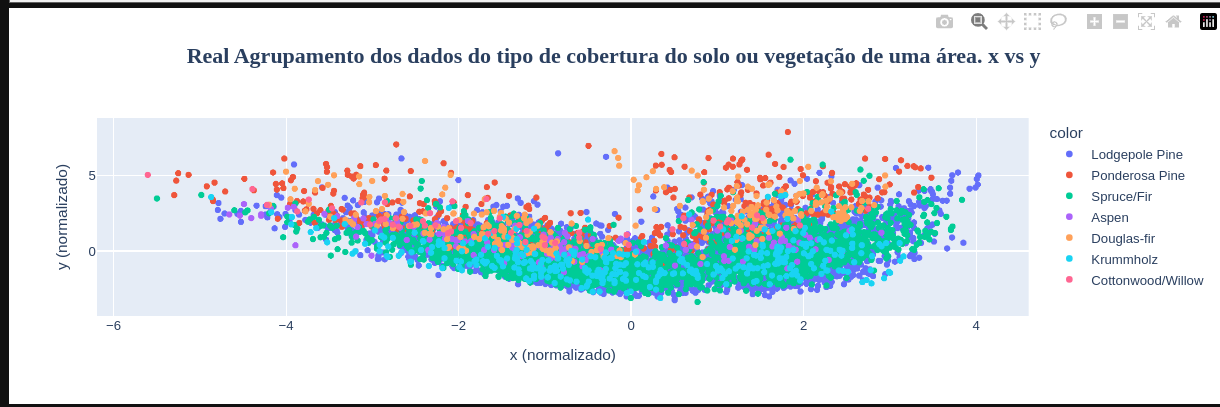

## Agora treine um algoritmo DBSCAN, com `eps=0.95` e `min_samples=2`.

In [71]:
dbscan = DBSCAN(eps=0.95, min_samples=2)
dbscan.fit(X)

DBSCAN(eps=0.95, min_samples=2)

In [72]:
dbscan.get_params()

{'algorithm': 'auto',
 'eps': 0.95,
 'leaf_size': 30,
 'metric': 'euclidean',
 'metric_params': None,
 'min_samples': 2,
 'n_jobs': None,
 'p': None}

In [73]:
labels = dbscan.labels_

In [74]:
set(labels)

{-1,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 

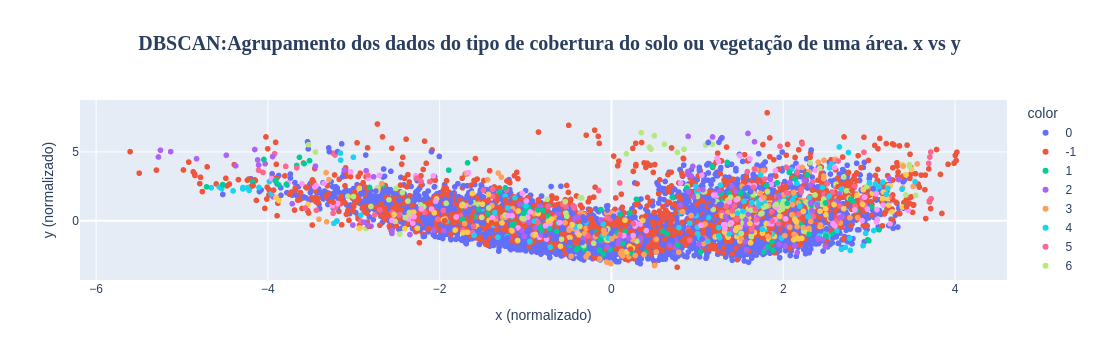

In [75]:
fig = px.scatter(x=X_pca[:, 0], y=X_pca[:, 1], color=labels.astype(str), title='<b>DBSCAN:Agrupamento dos dados do tipo de cobertura do solo ou vegetação de uma área. x vs y </b>')

fig.update_layout(
    xaxis_title_text='x (normalizado)',
    yaxis_title_text='y (normalizado)',
    # padrão o título
    title_font_size=20,  # Define o tamanho da fonte do título
    title_font_family='Arial Black', # Uma fonte mais grossa
    title_x=0.5 # Centraliza o título no gráfico
)

fig.show()
fig.write_html("Figuras/19exercicio_grafico3.html")

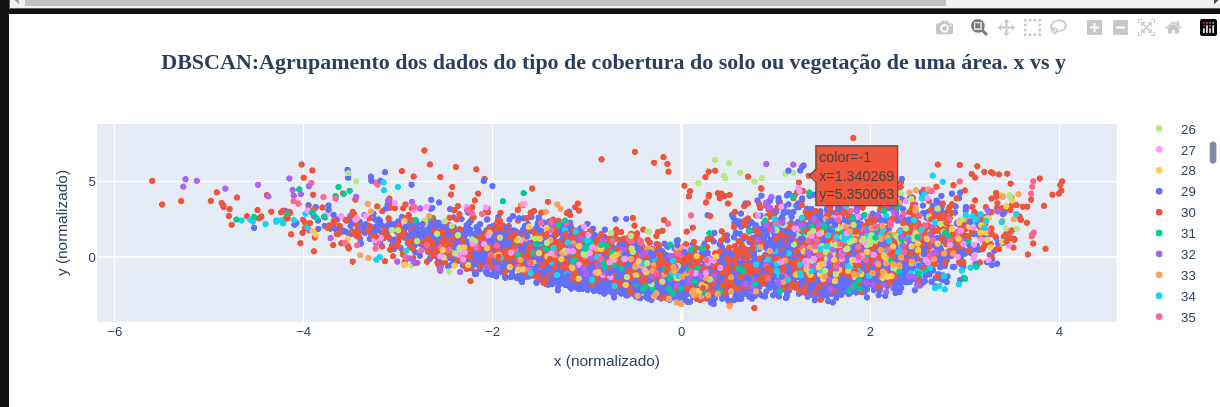

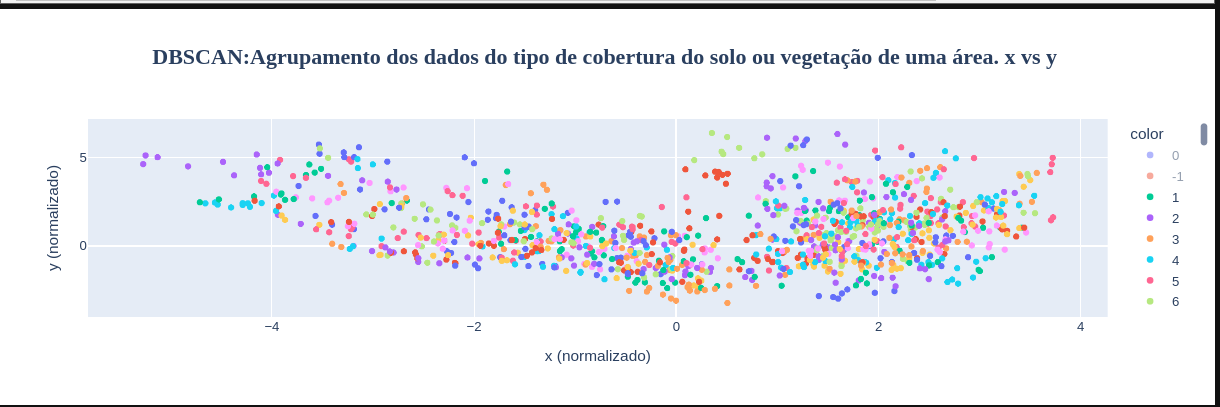

In [76]:
dbscan = DBSCAN(eps=1.7, min_samples=2)
dbscan.fit(X)
labels = dbscan.labels_
set(labels) # radical demais, ficou tudo no grupo 0

{-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12}

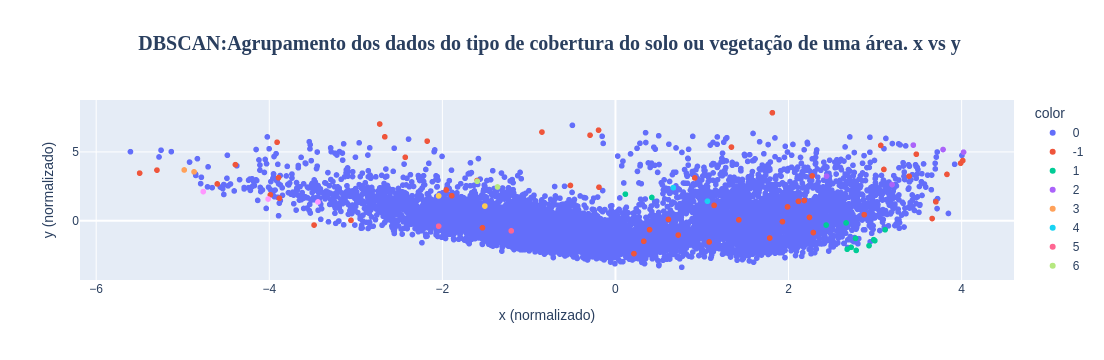

In [77]:
fig = px.scatter(x=X_pca[:, 0], y=X_pca[:, 1], color=labels.astype(str), title='<b>DBSCAN:Agrupamento dos dados do tipo de cobertura do solo ou vegetação de uma área. x vs y </b>')

fig.update_layout(
    xaxis_title_text='x (normalizado)',
    yaxis_title_text='y (normalizado)',
    # padrão o título
    title_font_size=20,  # Define o tamanho da fonte do título
    title_font_family='Arial Black', # Uma fonte mais grossa
    title_x=0.5 # Centraliza o título no gráfico
)

fig.show()
fig.write_html("Figuras/19exercicio_grafico4.html")

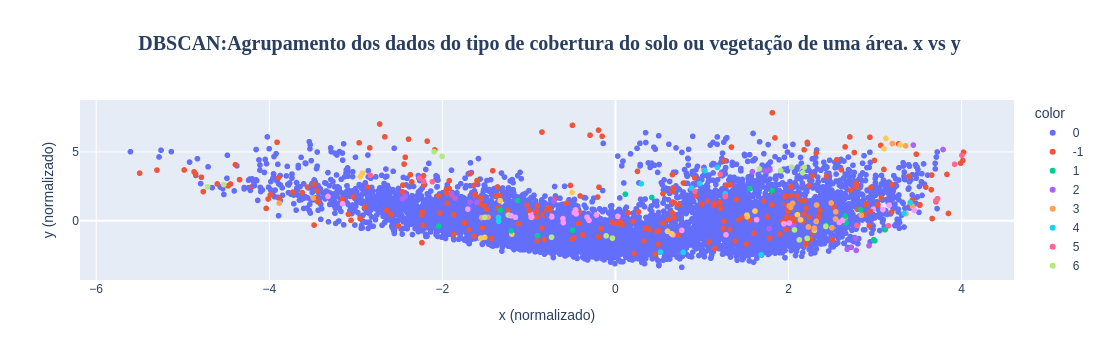

In [78]:
dbscan = DBSCAN(eps=1.3, min_samples=2)
dbscan.fit(X)
labels = dbscan.labels_
set(labels)

fig = px.scatter(x=X_pca[:, 0], y=X_pca[:, 1], color=labels.astype(str), title='<b>DBSCAN:Agrupamento dos dados do tipo de cobertura do solo ou vegetação de uma área. x vs y </b>')

fig.update_layout(
    xaxis_title_text='x (normalizado)',
    yaxis_title_text='y (normalizado)',
    # padrão o título
    title_font_size=20,  # Define o tamanho da fonte do título
    title_font_family='Arial Black', # Uma fonte mais grossa
    title_x=0.5 # Centraliza o título no gráfico
)

fig.show()
fig.write_html("Figuras/19exercicio_grafico5.html")